#  Лабораторная работа №2 «ДВПФ и ДПФ»
Курс: «Радиофизическая лаборатория» ФРКТ МФТИ


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import sys

sys.path.append(r"D:\git\MIPT\tools")

import plot_tools

array([1, 2, 3, 2, 1])

In [17]:
nu_vec2

array([ 0.        ,  0.00048828,  0.00097656, ..., -0.00146484,
       -0.00097656, -0.00048828], shape=(2048,))

In [22]:
nu_vec1

array([ 0. ,  0.2,  0.4, -0.4, -0.2])

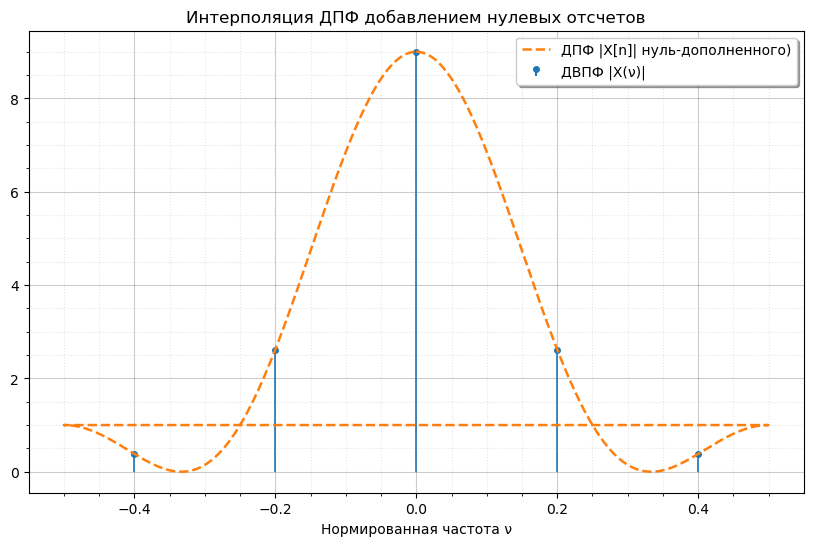

In [21]:
x_arr = np.array([1, 1, 1])

conv = np.convolve(x_arr, x_arr)

nu_vec1, spec = plot_tools.compute_dtft_analysis(conv, dtft_points=5, should_shift=False, as_stem=True)
nu_vec2, spec_cont = plot_tools.compute_dtft_analysis(conv, should_shift=False, as_stem=True)


plot_tools.plot_signals(
    y=[np.abs(spec), np.abs(spec_cont)],
    x=[nu_vec1, nu_vec2],
    labels=['ДВПФ |X(ν)|', f'ДПФ |X[n]| нуль-дополненного)'],
    linestyles=['-', '--'],
    title='Интерполяция ДПФ добавлением нулевых отсчетов',
    xlabel='Нормированная частота ν',
    as_stem=[True, False]
)


In [6]:
spec

array([ 9.        +0.j        , -2.11803399-1.53884177j,
        0.11803399+0.36327126j,  0.11803399-0.36327126j,
       -2.11803399+1.53884177j])

# Занятие 1. Основные свойства ДВПФ
Далее значения $N$, $L$, ${{\nu }_{0}}$ следует использовать из таблицы в соответствии с Вашим вариантом задания.

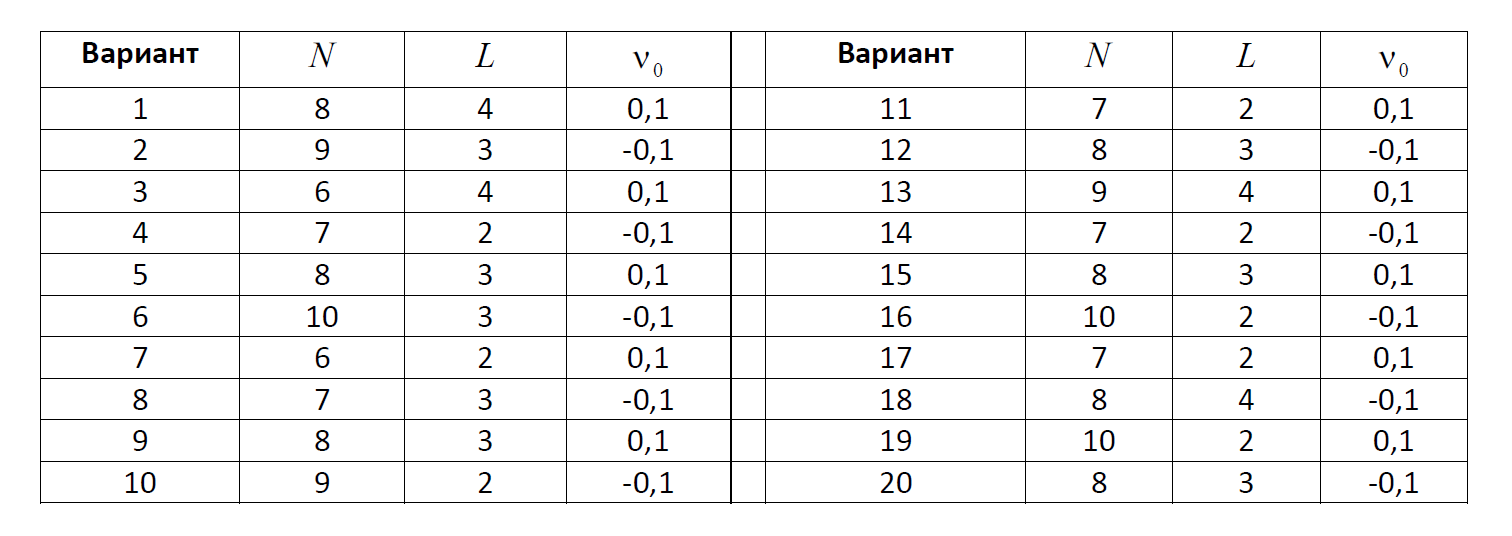

In [71]:
Nv = 3  # номер варианта

N_var = 6
L_var = 4      
nu0_var = 0.1   

## Задача 1.1.  Прямоугольный импульс в дискретной форме.  

С помощью моделирования  вычислите и постройте график для модуля и фазы ДВПФ  $X_N(\nu)$  последовательности из $N$ последовательных единичных импульсов ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ для $\nu \in [-0,5; \;0,5]$.  Сравните результат с аналитической записью для  $X_N(\nu)$ (задача 1.б из задания к допуску).  Заполнить таблицу, используя результаты моделирования и аналитические записи. Принять частоту дискретизации равной 1 Гц. 

*   **Значение X(0):** 6.0 (равно числу импульсов $N$).
*   **Ширина главного лепестка:** 0.3333 (вычисляется как $2/N = 1/3$).
*   **Точки скачков фазы на $\pi$:** ±0.1666 и ±0.3333 (это нули спектра, точки $k/N$).
*   **Энергия ($\times \Delta t$):** 6.0 (сумма квадратов амплитуд $1^2 \cdot 6$).

$^2$ Для дискретного сигнала рассматривают энергию $\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $, приходящуюся на один период частоты, т.е. на полосу частот шириной ${{f}_{\text{д}}}$:

$\int_{-0,5{{f}_{\text{д}}}}^{0,5{{f}_{\text{д}}}}{|}X(f){{|}^{2}}df=\frac{1}{\Delta t}\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $
Для ее вычисления можно воспользоваться равенством Парсеваля для ДВПФ. 


In [72]:
def analytical_rect_dtft(freq_vec, n_len):
    
    magnitude = np.sin(np.pi * freq_vec * n_len) / np.sin(np.pi * freq_vec)
    # Заменяем значение в нуле (где freq_vec == 0) на n_len
    magnitude = np.where(np.abs(freq_vec) < 1e-10, n_len, magnitude)
    
    phase_term = np.exp(-1j * np.pi * freq_vec * (n_len - 1))
    return magnitude * phase_term

C:\Users\Skifv\AppData\Local\Temp\ipykernel_11052\162970527.py:3: RuntimeWarning: invalid value encountered in divide
  magnitude = np.sin(np.pi * freq_vec * n_len) / np.sin(np.pi * freq_vec)


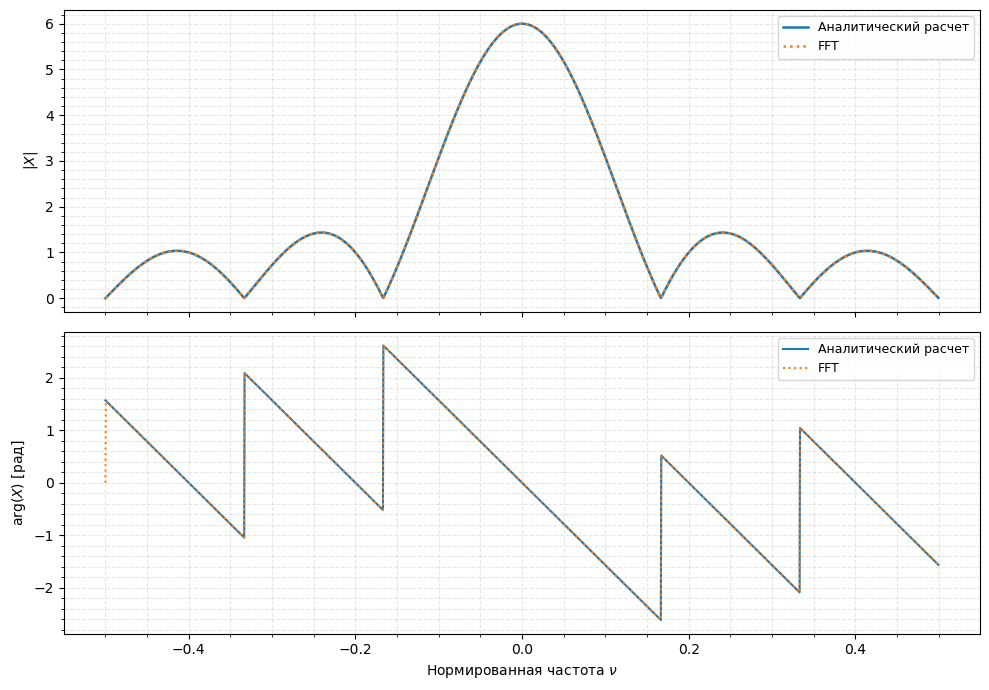

X(0): 6.00
Энергия (Интеграл): 6.0000
Энергия (Парсеваль): 6.00
Совпадают ли FFT и аналитика? True
Локальные минимумы [-0.33349609 -0.16650391  0.16650391  0.33349609]


In [73]:
x_n_vec = np.ones(N_var)

nu_vec, X_n_numeric = plot_tools.compute_dtft_analysis(x_n_vec, plot_results=False)
X_n_analytic = analytical_rect_dtft(nu_vec, N_var)

plot_tools.plot_dtft_analysis(nu_vec, [X_n_analytic, X_n_numeric], labels=['Аналитический расчет', 'FFT'], linestyles=["-", ":"], plot_phase=True)

energy_val = sp.integrate.simpson(y=np.abs(X_n_numeric)**2, x=nu_vec)
print(f"X(0): {np.abs(X_n_numeric[len(nu_vec)//2]):.2f}")
print(f"Энергия (Интеграл): {energy_val:.4f}")
print(f"Энергия (Парсеваль): {np.sum(x_n_vec**2):.2f}")

print(f"Совпадают ли FFT и аналитика? {np.isclose(X_n_analytic, X_n_numeric).all()}")

indicies, _ = sp.signal.find_peaks(-np.abs(X_n_numeric))

print(f"Локальные минимумы {nu_vec[indicies]}")

## Задача 1.2.  Свойство масштабирования. 

Постройте последовательность ${{x}_{L}}[k]=\sum\limits_{m=-\infty }^{\infty }{{{x}_{N}}}[m]\mathbf{1}[k-mL]$, добавив $L-1$ нулевой отсчет между каждой парой соседних отсчетов сигнала ${{x}_{N}}[k]$ (из задачи 1.1). С помощью моделирования постройте модуль ее ДВПФ для $\nu \in [-0,5; \;0,5]$ и сравните результат с ${{X}_{N}}(\nu L)$ (из задачи 1.1).


C:\Users\Skifv\AppData\Local\Temp\ipykernel_11052\162970527.py:3: RuntimeWarning: invalid value encountered in divide
  magnitude = np.sin(np.pi * freq_vec * n_len) / np.sin(np.pi * freq_vec)


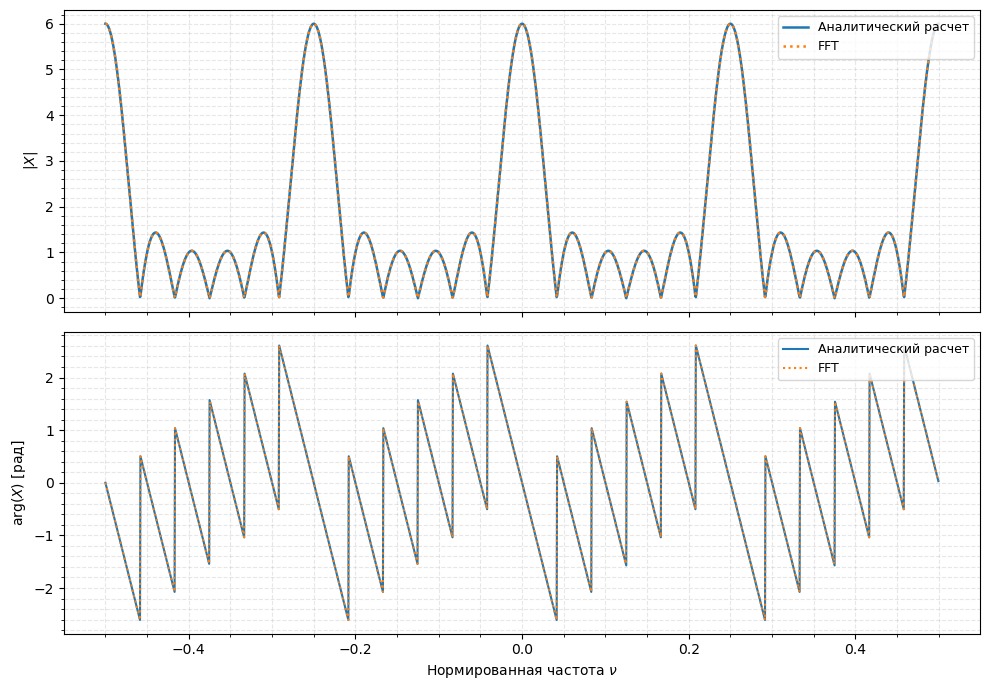

In [74]:
x_l_vec = np.zeros(N_var + (N_var - 1) * (L_var - 1))
x_l_vec[::L_var] = x_n_vec

nu_l_vec, X_l_numeric = plot_tools.compute_dtft_analysis(x_l_vec, plot_results=False, dtft_points=2048)
X_l_theoretical = analytical_rect_dtft(nu_l_vec * L_var, N_var)

plot_tools.plot_dtft_analysis(nu_l_vec, [X_l_theoretical, X_l_numeric], labels=['Аналитический расчет', 'FFT'], linestyles=["-", ":"], plot_phase=True)

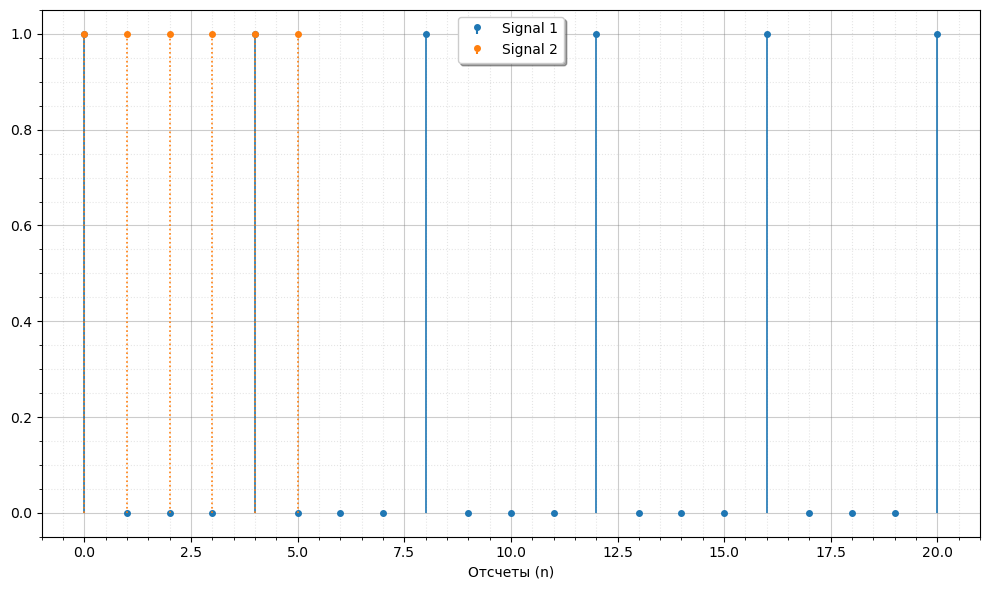

In [75]:
plot_tools.plot_signals([x_l_vec, x_n_vec], linestyles=["-", ":"], as_stem=True)

In [76]:
np.isclose(X_l_theoretical, X_l_numeric).all()

np.True_

## Задача 1.3.  Дифференцирование спектральной плотности.
Рассмотрите последовательность ${{x}_{D}}[k]=k\,{{x}_{N}}[k]$.  Постройте с помощью моделирования график для модуля ДВПФ этой последовательности ${{X}_{D}}(\nu )$ для $\nu \in [-0,5; \;0,5]$. 

** Получить численным или символьным дифференцированием график для $\frac{j}{2\pi }\frac{d{{X}_{N}}(\nu )}{d\nu }$ и сравнить его с ${{X}_{D}}(\nu ).$ 


Совпадают? False


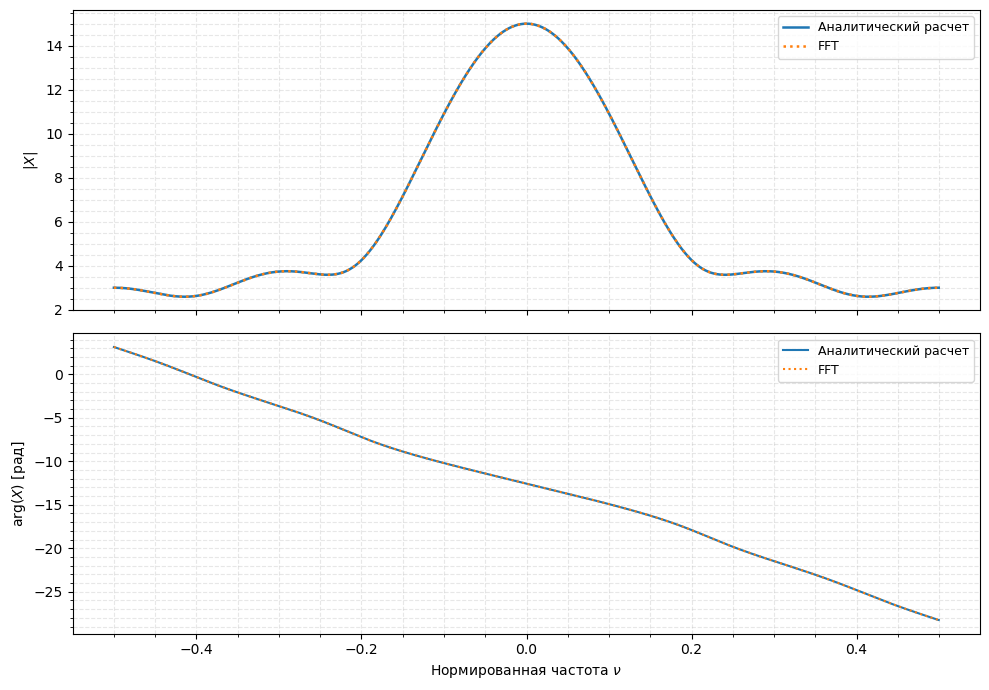

In [77]:
k_indices = np.arange(N_var)
x_d_vec = k_indices * x_n_vec

nu_d_vec, X_d_numeric = plot_tools.compute_dtft_analysis(x_d_vec)

# dX/d_nu ≈ (X[i+1] - X[i-1]) / (2 * delta_nu)
dX_dnu = np.gradient(X_n_numeric, nu_d_vec[1] - nu_d_vec[0])
X_d_theoretical = (1j / (2 * np.pi)) * dX_dnu

print(f"Совпадают? {np.isclose(X_d_numeric, X_d_theoretical).all()}")

plot_tools.plot_dtft_analysis(nu_d_vec, [X_d_theoretical, X_d_numeric], labels=['Аналитический расчет', 'FFT'], linestyles=["-", ":"], plot_phase=True)

## Задача 1.4. Теорема смещения.
С помощью моделирования получите график модуля спектральной плотности ${{X}_{S}}(\nu )$ для сигнала ${{x}_{S}}[k]={{x}_{N}}[k]\exp (j2\pi {{\nu }_{0}}k)$. Приведите ответы на следующие вопросы.

а) Какую аналитическую форму записи имеет функция ${{X}_{S}}(\nu )$?

Аналитическая форма: X_S(v) = X_N(v - v0). Спектр сдвигается вправо на v0

б) Как результат моделирования соотносится с теоремой смещения для ДВПФ? 

Результат подтверждает теорему смещения: главный лепесток теперь на частоте v0

в) Почему получившийся спектр не симметричен относительно нулевой частоты? 

Спектр не симметричен, так как сигнал стал комплексным. Симметрия верна только для вещественных сигналов.

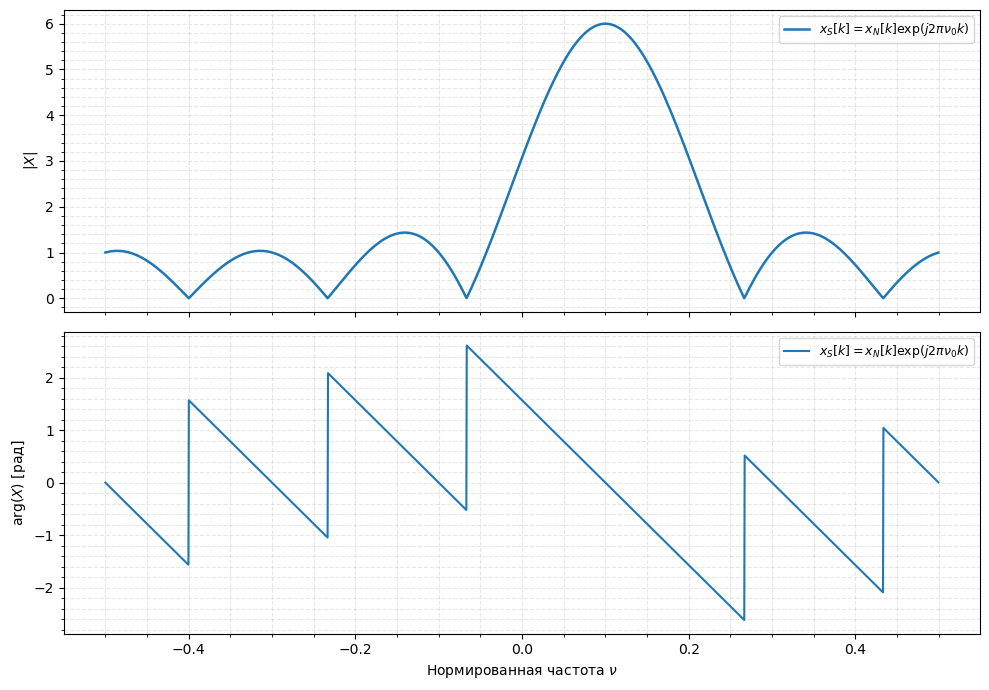

In [78]:
x_s_vec = x_n_vec * np.exp(1j * 2 * np.pi * nu0_var * k_indices)

# Вычисление ДВПФ
nu_s_vec, X_s_numeric = plot_tools.compute_dtft_analysis(x_s_vec, labels=r"${{x}_{S}}[k]={{x}_{N}}[k]\exp (j2\pi {{\nu }_{0}}k)$", plot_results=True, plot_phase=True)

## Задача 1.5. Теорема о свертке во временной области. 

Вычислите с помощью моделирования линейную дискретную свертку последовательности ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ с точно такой же последовательностью. Постройте график для модуля ДВПФ  этой последовательности. Воспользовавшись теоремой о свертке, получите аналитическую запись ДВПФ. Заполните таблицу.

*   **Значение X(0): 36.0**
    По теореме о свертке спектры перемножаются: $X(0) = X_N(0) \cdot X_N(0) = 6 \cdot 6 = 36$.
*   **Ширина главного лепестка $\Delta\nu$: 0.4**
    Точки первых нулей спектра $\pm 1/N = \pm 0.16699219$ не меняются при возведении в квадрат. Ширина: $0.33300781$.
*   **Энергия $\times \Delta t$: 85.0**
    По равенству Парсеваля равна сумме квадратов отсчетов треугольного импульса во времени: $146.00$.

Совпадают? True


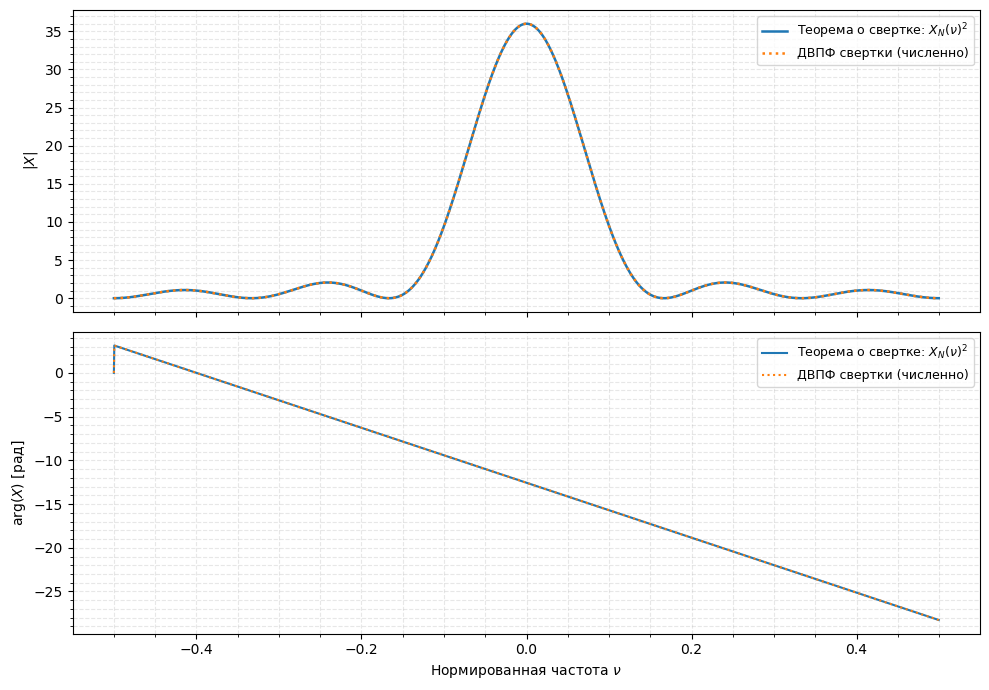

X_conv(0): 36.00
Энергия (Парсеваль): 146.00
Энергия (Интеграл): 146.0000
Локальные минимумы [-0.33349609 -0.16650391  0.16650391  0.33349609]


In [79]:
x_conv_vec = np.convolve(x_n_vec, x_n_vec)

nu_conv, [X_conv_num, X_n_for_conv] = plot_tools.compute_dtft_analysis([x_conv_vec, x_n_vec])

X_conv_theory = X_n_for_conv ** 2

print(f"Совпадают? {np.isclose(X_conv_theory, X_conv_num).all()}")

plot_tools.plot_dtft_analysis(nu_conv, [X_conv_theory, X_conv_num], labels=[r'Теорема о свертке: $X_N(\nu)^2$', 'ДВПФ свертки (численно)'], linestyles=["-", ":"], plot_phase=True)

print(f"X_conv(0): {np.abs(X_conv_num[len(nu_conv)//2]):.2f}")
print(f"Энергия (Парсеваль): {np.sum(x_conv_vec**2):.2f}")
print(f"Энергия (Интеграл): {sp.integrate.simpson(y=np.abs(X_conv_num)**2, x=nu_conv):.4f}")

indicies = sp.signal.argrelmin(np.abs(X_n_numeric))
print(f"Локальные минимумы {nu_vec[indicies]}")

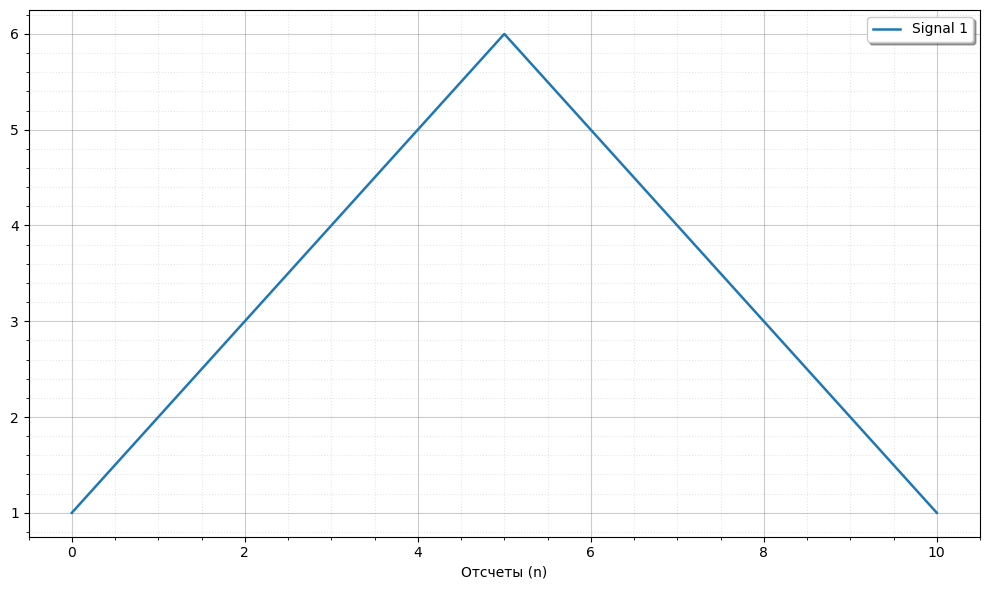

In [80]:
plot_tools.plot_signals(x_conv_vec)

# Занятие 2. Основные свойства ДПФ

Для задач 2.1 и 2.2 последовательность $x[k]$ генерируется с помощью следующего кода. 

In [81]:
# Nv - номер варианта
x = np.random.rand(Nv+32)-0.5
x

array([-0.44962938,  0.24373281,  0.33478708, -0.33096155,  0.29798518,
       -0.49595202, -0.41688495, -0.44535714,  0.44870835, -0.05170054,
       -0.2786355 , -0.43194612,  0.23653161, -0.19948721,  0.0994873 ,
        0.4857958 ,  0.2368395 , -0.01424066, -0.33026315, -0.3354971 ,
       -0.34976272, -0.02878539,  0.35612543,  0.41586579, -0.22690838,
       -0.42087743,  0.12005833, -0.22203718, -0.43131374,  0.46610093,
       -0.49681657, -0.29413528,  0.47087089, -0.07152402, -0.14653395])

In [96]:
x.shape

(35,)

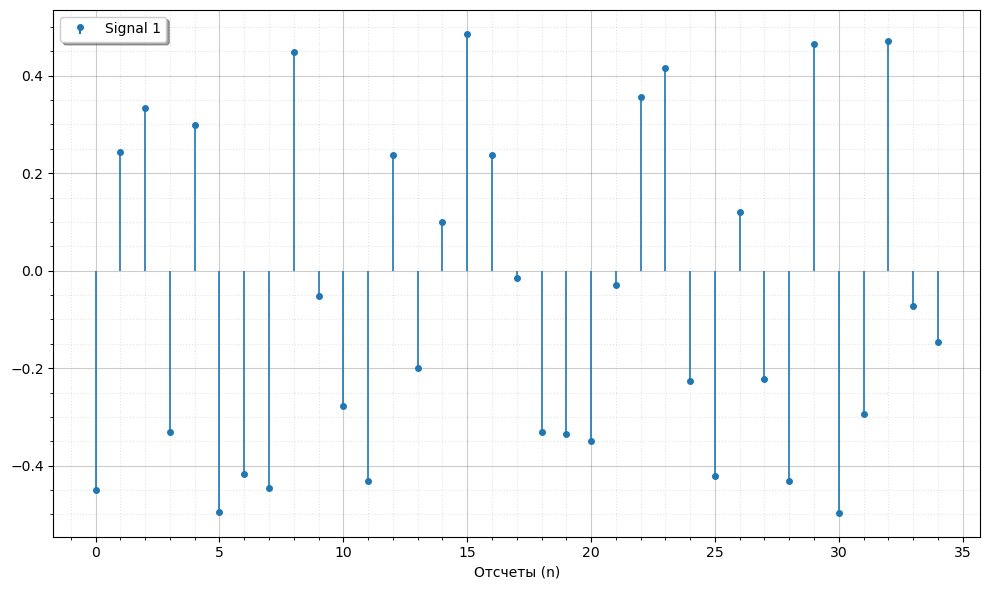

In [82]:
plot_tools.plot_signals(x, as_stem=True)

## Задача 2.1. Алгоритмы вычисления ДПФ. 

Вычислите ДПФ $X[n]$ для последовательности $x[k]$. Воспользуйтесь следующими способами:

а) вычисление с использованием матричной формы ДПФ;

б) алгоритм быстрого преобразование Фурье (БПФ).

Сравните результаты. 


In [83]:
def dft(x):
    M_points = len(x)
    n_arr = np.arange(M_points)
    k_arr = np.arange(len(x))
    n_k_mat = np.outer(n_arr, k_arr)
    W_nk_mat = np.exp(-1j * 2 * np.pi / M_points * n_k_mat)

    return W_nk_mat @ x
    

In [84]:
    M_points = len(x)
    n_arr = np.arange(M_points)
    k_arr = np.arange(len(x))
    n_k_mat = np.outer(n_arr, k_arr)
    W_nk_mat = np.exp(-1j * 2 * np.pi / M_points * n_k_mat)

In [85]:
M_points = len(x)

# а) матричная форма

X_arr_my = dft(x)

# б) БПФ

nu_vec, X_arr_FFT = plot_tools.compute_dtft_analysis(x, dtft_points=M_points, should_shift=False)


In [86]:
nu_vec = np.fft.fftshift(nu_vec)

In [87]:
np.isclose(X_arr_FFT, X_arr_my).all()

np.True_

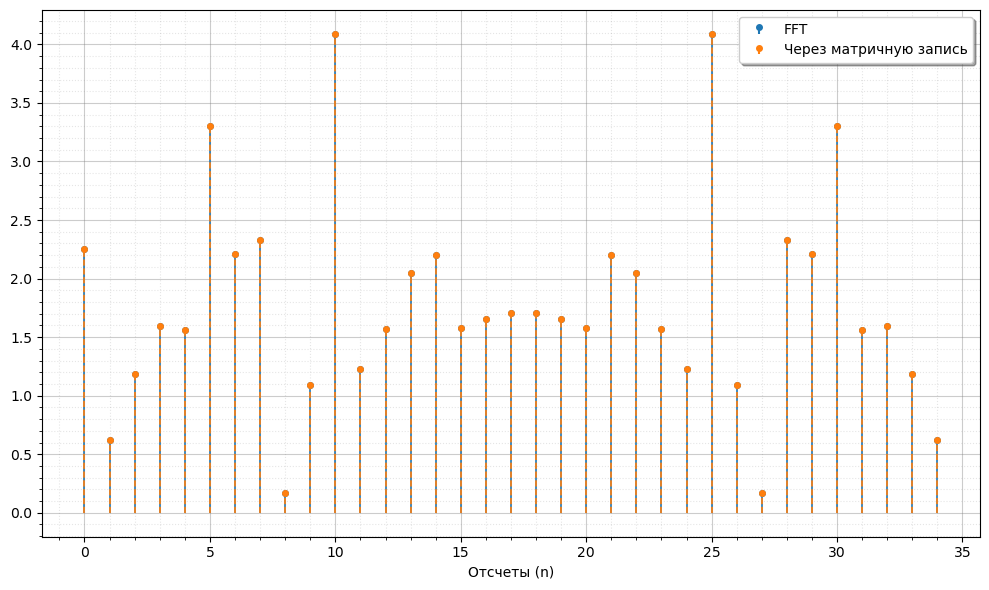

In [88]:
plot_tools.plot_signals([np.abs(X_arr_FFT), np.abs(X_arr_my)], labels=['FFT', 'Через матричную запись'], linestyles=['-', '--'], as_stem=True)


## Задача 2.2  Свойства симметрии ДПФ. 

Для последовательности $x[k]$ постройте графики $\text{Re}\ X[n]$, $\text{Im}\ X[n]$, $\left| X[n] \right|$, $\angle \ X[n]$.

Сравните получившиеся результаты со свойствами симметрии ДПФ. 


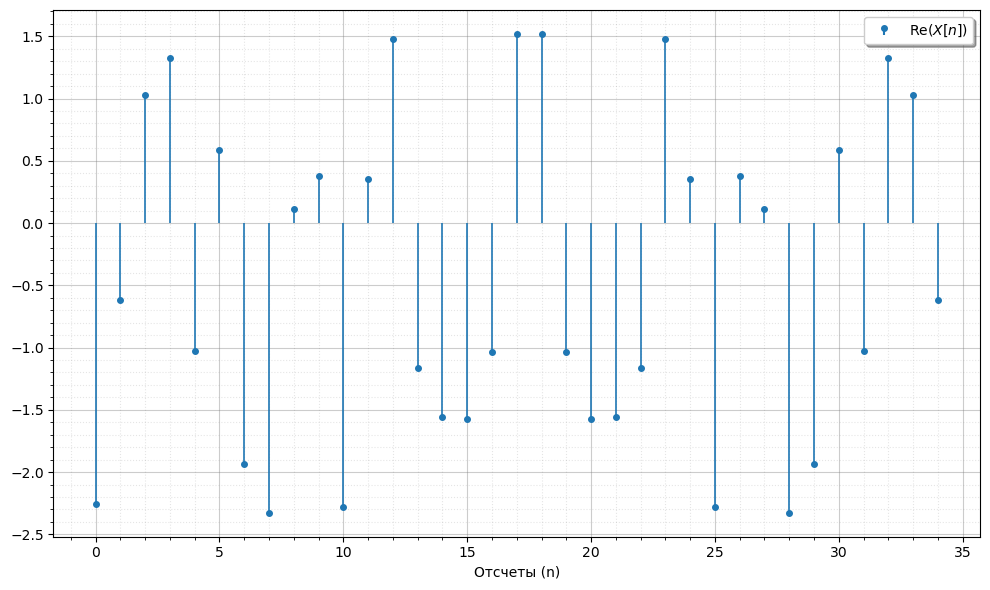

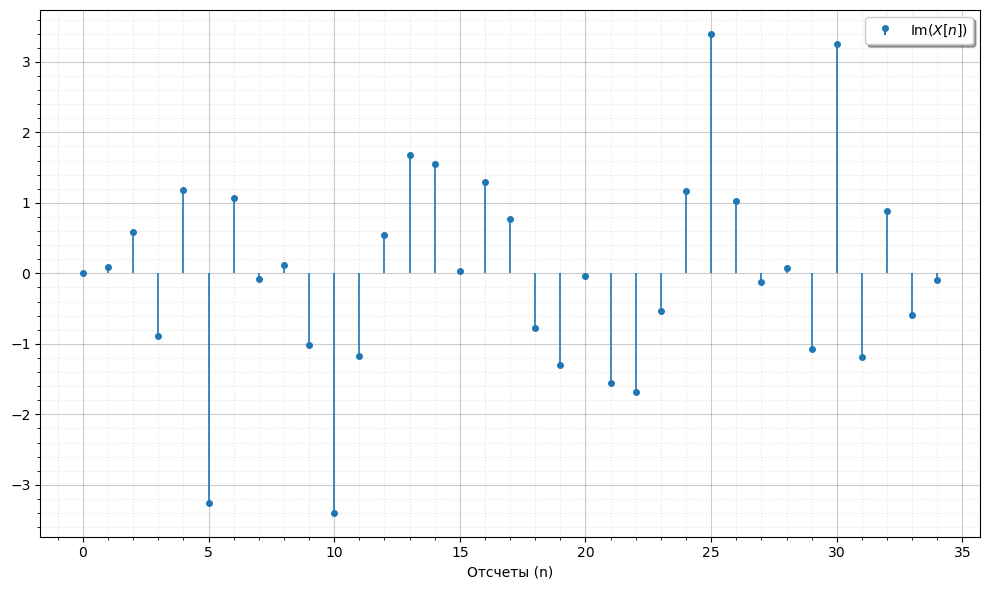

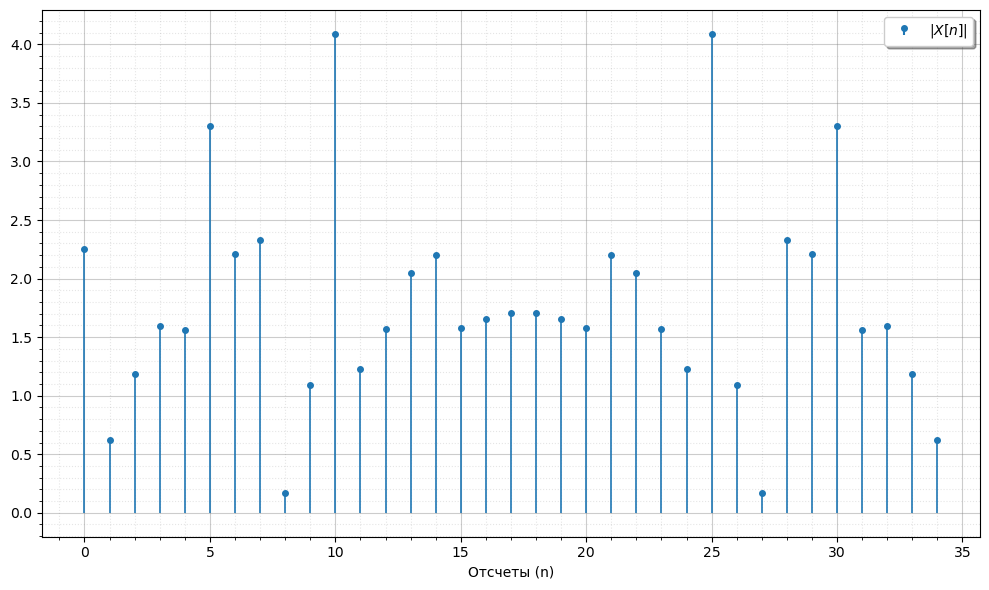

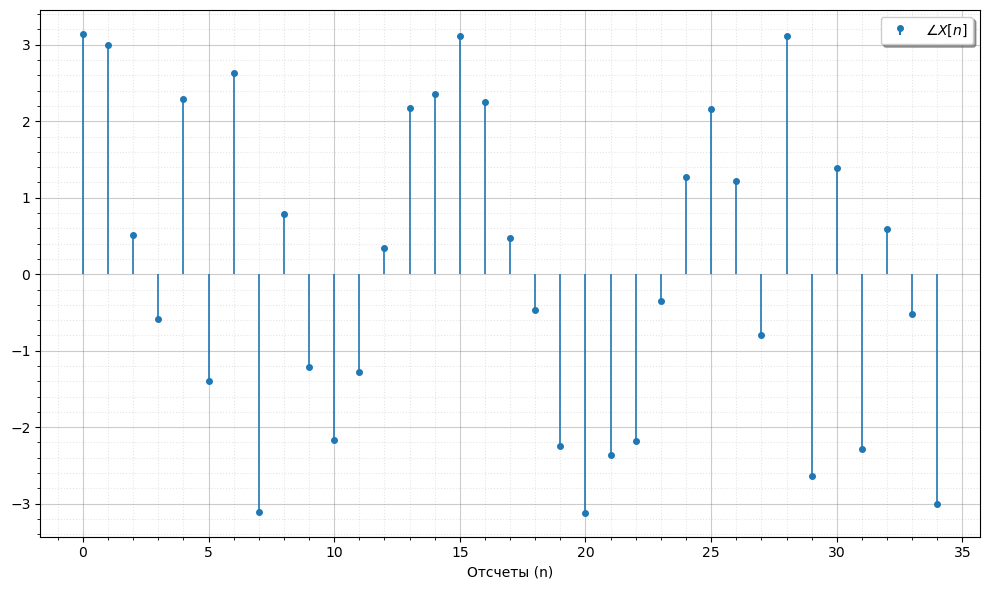

In [89]:
plot_tools.plot_signals(np.real(X_arr_FFT), labels=r'$\text{Re}(X[n])$', as_stem=True)
plot_tools.plot_signals(np.imag(X_arr_FFT), labels=r'$\text{Im}(X[n])$', as_stem=True)
plot_tools.plot_signals(np.abs(X_arr_FFT), labels=r'$|X[n]|$', as_stem=True)
plot_tools.plot_signals(np.angle(X_arr_FFT), labels=r'$\angle X[n]$', as_stem=True)

## Задача 2.3.  Циклический сдвиг в ДПФ. 


Постройте график для последовательности $q[k]=k+1$ при $0\le k < N_v$, иначе  $q[k]=0$.

Вычислите последовательность $y[k]$, ДПФ которой 
$Y[n]=\exp \left( -j\frac{2\pi }{Nv}mn \right)Q[n]$.

Сравните получившиеся последовательности. 


Параметр $m$ для задачи 2.3 генерируется с помощью следующего кода. 

In [100]:
Nv = 14 # Nv - номер варианта
m = max(Nv % 8, 1)
print("m =", m)

m = 6


In [101]:
x_arr = np.array([0, 1, 2])

np.roll(x_arr, shift=1)

array([2, 0, 1])

m = 6, Nv = 14
q[k]: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
y[k]: [ 9. 10. 11. 12. 13. 14.  1.  2.  3.  4.  5.  6.  7.  8.]


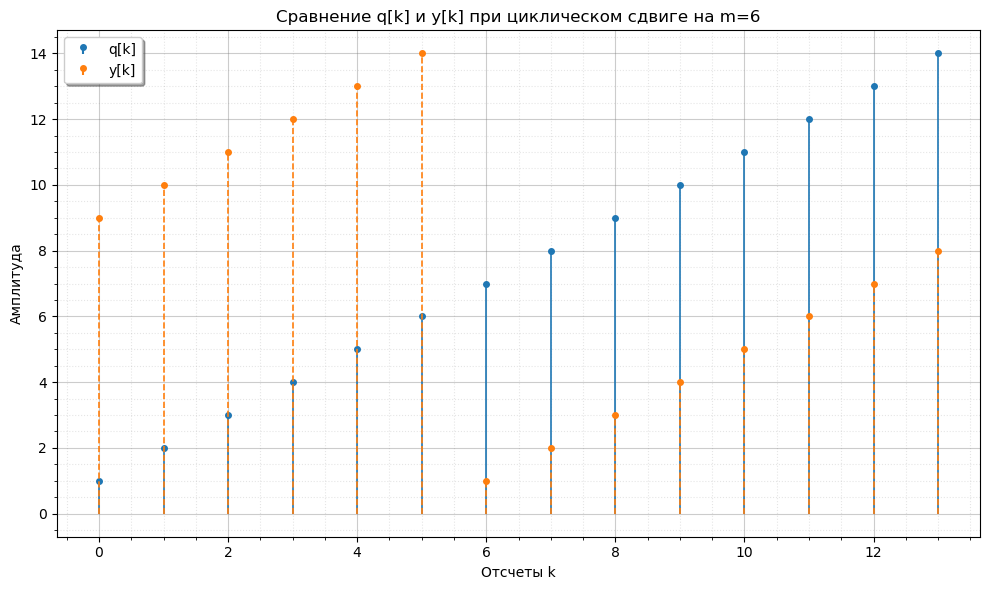

In [102]:
N_seq = Nv

k_arr = np.arange(N_seq)
q_k = k_arr + 1

Q_n = np.fft.fft(q_k)

n_arr = np.arange(N_seq)
Y_n = Q_n * np.exp(-1j * 2 * np.pi / N_seq * m * n_arr)

y_k = np.fft.ifft(Y_n).real

print(f"m = {m}, Nv = {N_seq}")
print(f"q[k]: {q_k}")
print(f"y[k]: {np.round(y_k, 4)}")

plot_tools.plot_signals(
    y=[q_k, y_k],
    x=k_arr,
    labels=['q[k]', 'y[k]'],
    linestyles=['-', '--'],
    title=f'Сравнение q[k] и y[k] при циклическом сдвиге на m={m}',
    xlabel='Отсчеты k',
    ylabel='Амплитуда',
    as_stem=True
)

# Занятие 3. Связь ДВПФ и ДПФ

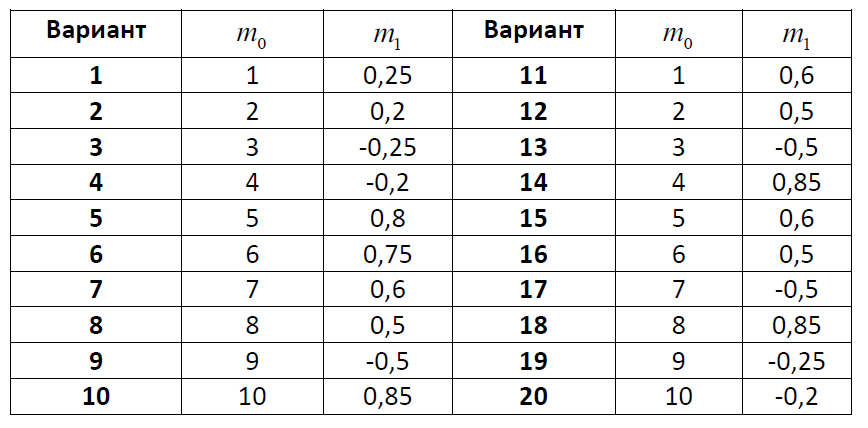

## Задача 3.1. Интерполяция  ДВПФ добавлением нулевых отсчетов в сигнал.

Постройте на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$ последовательности ($N=32$)
$$x[k] = \begin{cases} \sin \left( \frac{2\pi}{N} m_0 k \right) + \sin \left( \frac{2\pi}{N} (m_0 + 0,25) k \right), & 0 \le k \le N-1; \\ 0, & \text{в остальных случаях.} \end{cases}$$
Увеличьте размерность ДПФ, добавив нулевые отсчеты так, чтобы все относительные частоты синусоид попадали на бины ДПФ.  Приведите на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$  для этого случая. Сравните результаты. 

Они не попадут!! Бины не разрешимы по критерию Релея

In [119]:
X_dft_padded.shape

(1056,)

In [116]:
%notebook widget

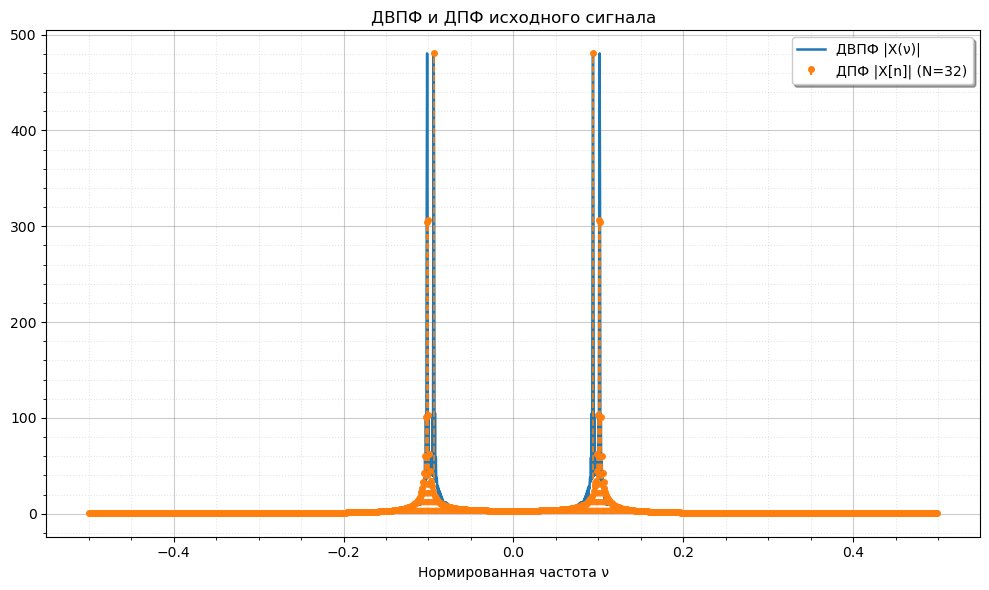

ValueError: could not broadcast input array from shape (1056,) into shape (128,)

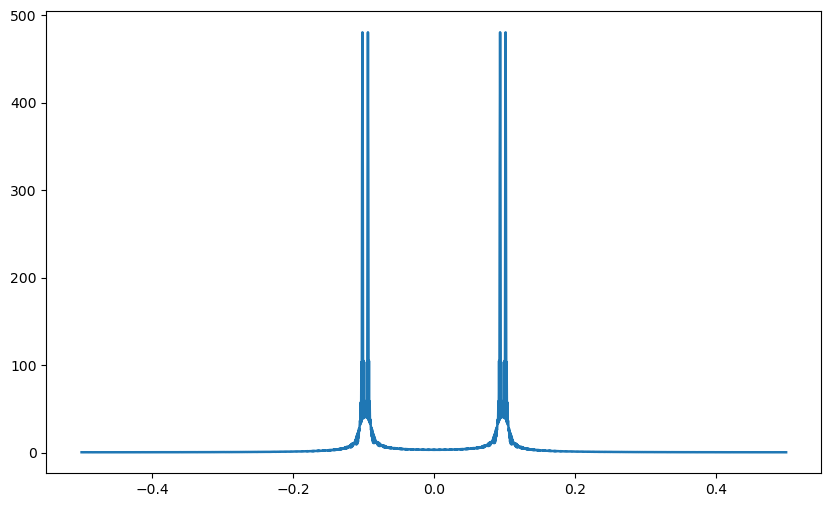

In [118]:
N = 32
s=30
m0 = 3
k_arr = np.arange(s*N)

x_k = np.sin(2 * np.pi / N * m0 * k_arr) + np.sin(2 * np.pi / N * (m0 + 0.25) * k_arr)

nu_dtft, X_dtft = plot_tools.compute_dtft_analysis(x_k, dtft_points=2048, plot_results=False)

nu_dft = np.fft.fftshift(np.fft.fftfreq(N*s))
X_dft = np.fft.fftshift(np.fft.fft(x_k))

plot_tools.plot_signals(
    y=[np.abs(X_dtft), np.abs(X_dft)],
    x=[nu_dtft, nu_dft],
    labels=['ДВПФ |X(ν)|', f'ДПФ |X[n]| (N={N})'],
    linestyles=['-', '--'],
    title='ДВПФ и ДПФ исходного сигнала',
    xlabel='Нормированная частота ν',
    as_stem=[False, True]
)

# Частоты синусоид: f1 = m0/N = 3/32 = 12/128; f2 = (m0+0.25)/N = 3.25/32 = 13/128.
# Чтобы частоты точно попадали на бины ДПФ, размер ДПФ M должен быть кратен 128.
M = 128
x_k_padded = np.pad(x_k, (0, M - N))

# Вычисление ДПФ интерполированного сигнала
nu_dft_padded = np.fft.fftshift(np.fft.fftfreq(M))
X_dft_padded = np.fft.fftshift(np.fft.fft(x_k_padded))

# Визуализация 2: Модули ДВПФ и интерполированного ДПФ на одном графике
plot_tools.plot_signals(
    y=[np.abs(X_dtft), np.abs(X_dft_padded)],
    x=[nu_dtft, nu_dft_padded],
    labels=['ДВПФ |X(ν)|', f'ДПФ |X[n]| нуль-дополненного (M={M})'],
    linestyles=['-', '--'],
    title='Интерполяция ДПФ добавлением нулевых отсчетов',
    xlabel='Нормированная частота ν',
    as_stem=[False, True]
)

## Задача 3.2. ДВПФ и ДПФ периодической последовательсти.

Простройте графики для действительной  и мнимой части коэффициентов ДПФ $\tilde{X}[n]$ периодической последовательности $x[k]=\cos \left( \frac{2\pi }{N}mk \right)+\sin \left( \frac{2\pi }{N}mk \right)$  с периодом $N=32$, для случаев $m={{m}_{0}}$ и $m={{m}_{0}}+{{m}_{1}}$. Получите аналитическую запись ДПФ. Сравните ДПФ последовательности с ее ДВПФ. Определите, выполняется ли связь между весами дельта-функций в ДВПФ и величинами отсчетов ДПФ. 


$$x[k] = \cos \left( \frac{2\pi}{N}mk \right) + \sin \left( \frac{2\pi}{N}mk \right) = \frac{e^{j\frac{2\pi}{N}mk} + e^{-j\frac{2\pi}{N}mk}}{2} + \frac{e^{j\frac{2\pi}{N}mk} - e^{-j\frac{2\pi}{N}mk}}{2j} = \frac{1-j}{2} e^{j\frac{2\pi}{N}mk} + \frac{1+j}{2} e^{-j\frac{2\pi}{N}mk}$$

По сути это обратное ДПФ для x[n] в случае целых m. Поэтому:
$$X[n] = \begin{cases} \frac{N}{2}(1-j), & n = m \\ \frac{N}{2}(1+j), & n = N-m \\ 0, & \text{для остальных } n \in [0, N-1] \end{cases}$$

ДВПФ при этом:

$$X_{\text{per}}(\nu) = \frac{1-j}{2} \delta\left(\nu - \frac{m}{N}\right) + \frac{1+j}{2} \delta\left(\nu - \frac{N-m}{N}\right)$$
с периодом N.

Если же m нецелый:
$$X[n] = \frac{1-j}{2} \sum_{k=0}^{N-1} e^{j\frac{2\pi}{N}(m-n)k} + \frac{1+j}{2} \sum_{k=0}^{N-1} e^{-j\frac{2\pi}{N}(m+n)k}$$

Но
$$S(\theta) = \sum_{k=0}^{N-1} e^{j\theta k} = \frac{1 - e^{j\theta N}}{1 - e^{j\theta}} = \frac{e^{j\theta N / 2} (e^{-j\theta N / 2} - e^{j\theta N / 2})}{e^{j\theta / 2} (e^{-j\theta / 2} - e^{j\theta / 2})} = e^{j\theta \frac{N-1}{2}} \cdot \frac{\sin(\theta N / 2)}{\sin(\theta / 2)}$$
Тогда
$$X[n] = \frac{1-j}{2} \left[ e^{j\pi(m-n)\frac{N-1}{N}} \frac{\sin(\pi(m-n))}{\sin\left(\frac{\pi(m-n)}{N}\right)} \right] + \frac{1+j}{2} \left[ e^{-j\pi(m+n)\frac{N-1}{N}} \frac{\sin(\pi(m+n))}{\sin\left(\frac{\pi(m+n)}{N}\right)} \right]$$

n=m: (15.999999999999993-16.00000000000001j)
n=N-m: (15.999999999999993+16.00000000000001j)


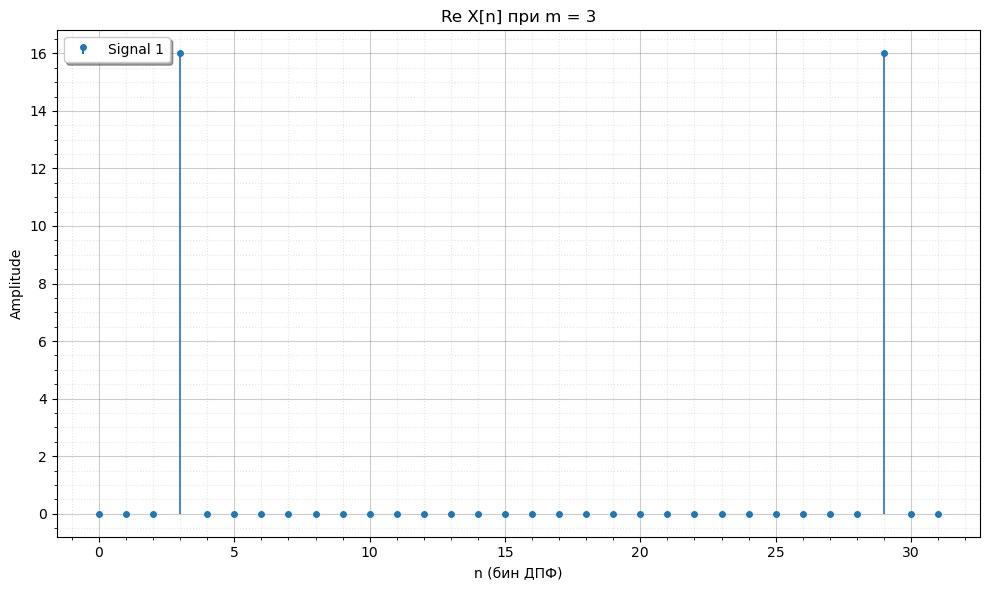

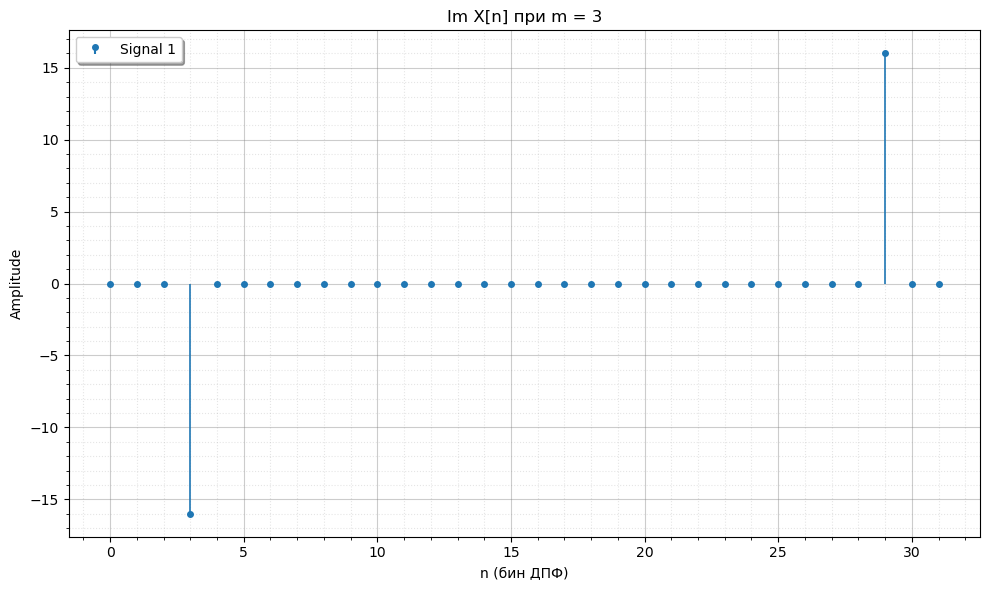

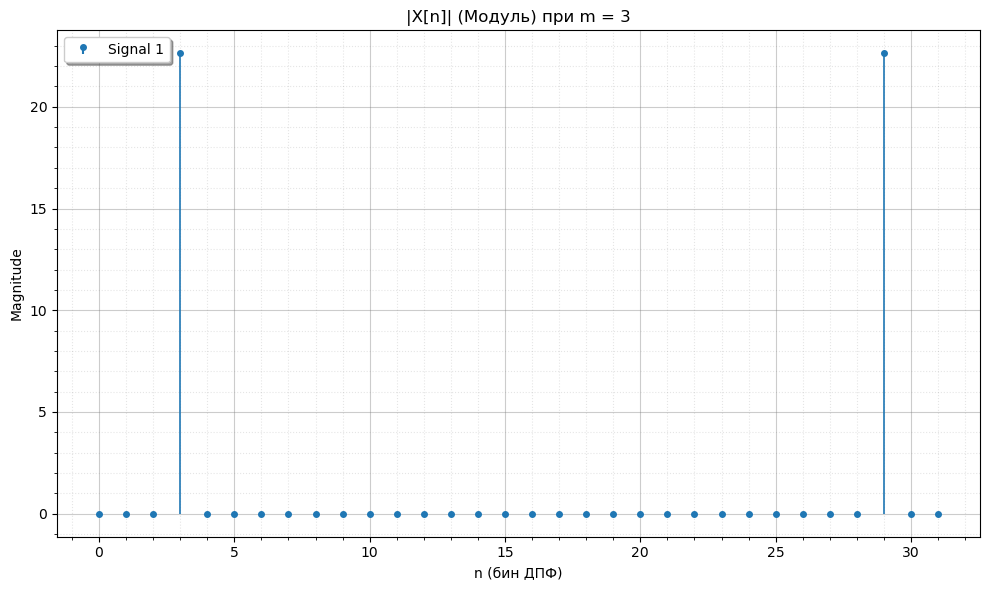

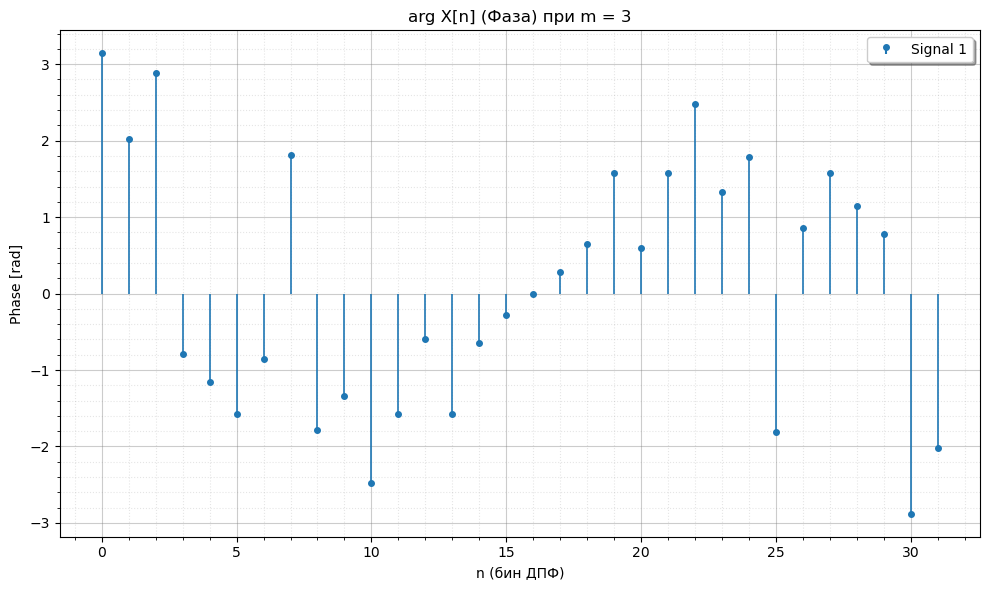

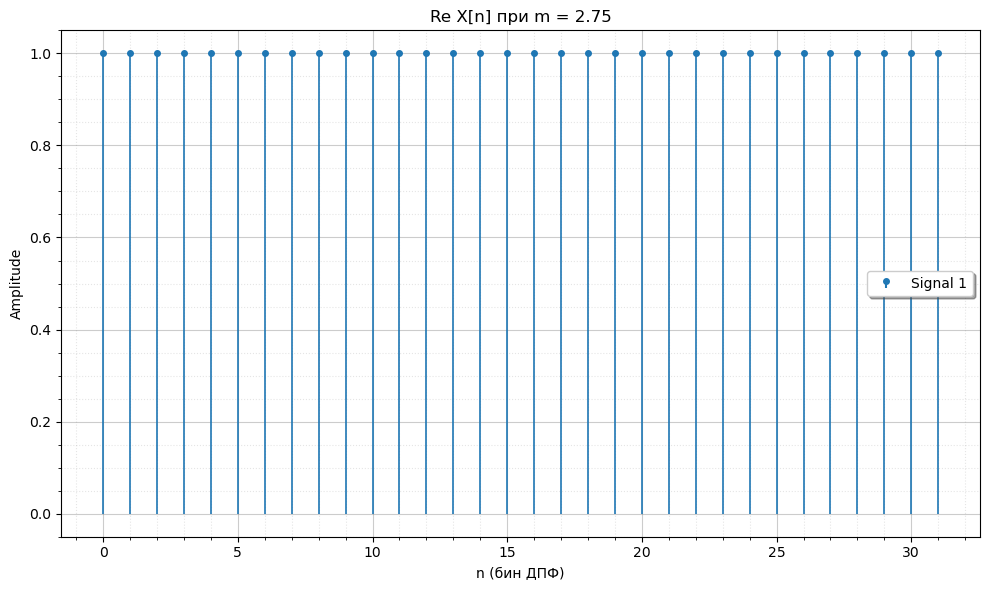

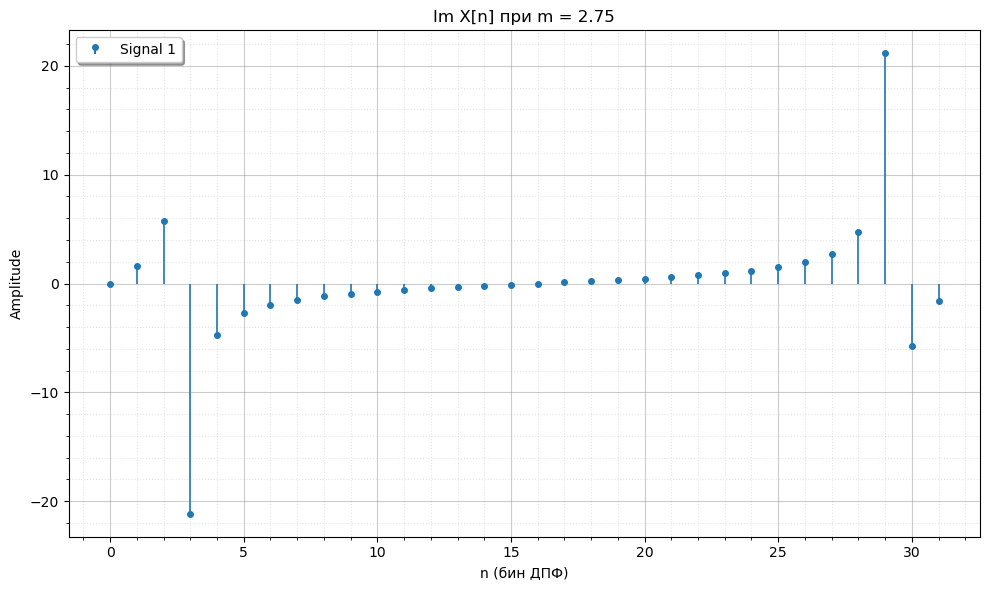

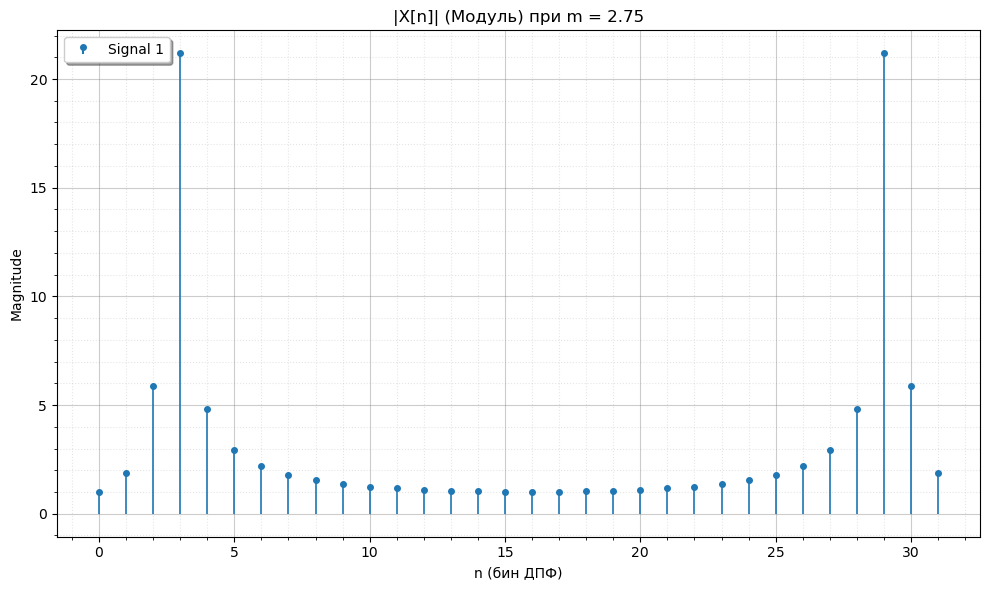

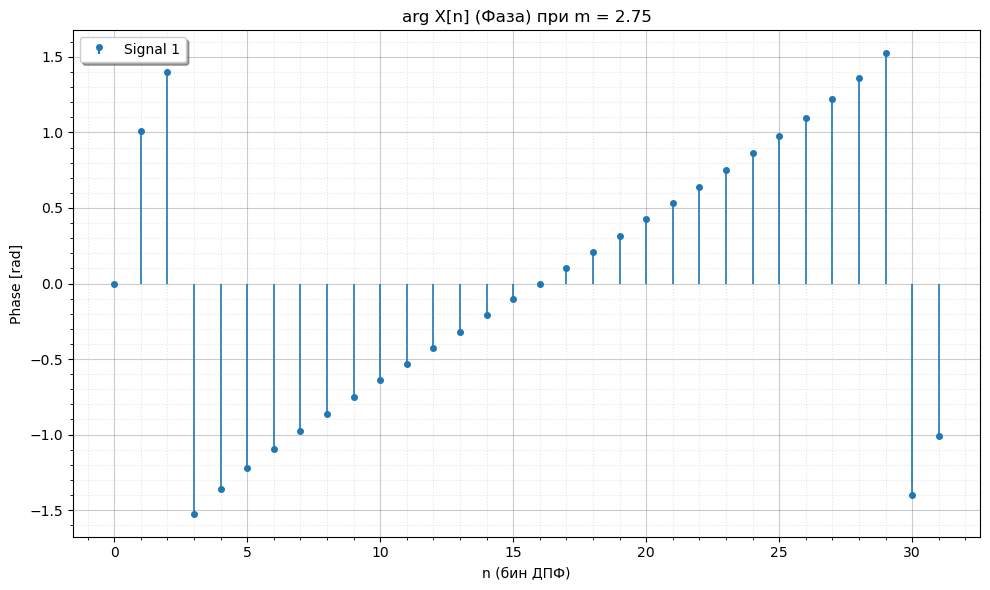

In [122]:
N = 32
m0 = 3
m1 = -0.25
k_arr = np.arange(N)

def analyze_periodic_signal(m, N_size):
    
    x_k = np.cos(2 * np.pi / N_size * m * k_arr) + np.sin(2 * np.pi / N_size * m * k_arr)

    X_n = np.fft.fft(x_k)
    n_arr = np.arange(N_size)
    
    if float(m).is_integer():
        print(f"n=m: {X_n[m]}")
        print(f"n=N-m: {X_n[N_size - m]}")

    plot_tools.plot_signals(np.real(X_n), x=n_arr, title=f'Re X[n] при m = {m}', xlabel='n (бин ДПФ)', ylabel='Amplitude', as_stem=True)
    plot_tools.plot_signals(np.imag(X_n), x=n_arr, title=f'Im X[n] при m = {m}', xlabel='n (бин ДПФ)', ylabel='Amplitude', as_stem=True)
    plot_tools.plot_signals(np.abs(X_n), x=n_arr, title=f'|X[n]| (Модуль) при m = {m}', xlabel='n (бин ДПФ)', ylabel='Magnitude', as_stem=True)
    plot_tools.plot_signals(np.angle(X_n), x=n_arr, title=f'arg X[n] (Фаза) при m = {m}', xlabel='n (бин ДПФ)', ylabel='Phase [rad]', as_stem=True)

# Запуск анализа для m0 (целое)
analyze_periodic_signal(m0, N)

# Запуск анализа для m0 + m1 (нецелое: 3 - 0.25 = 2.75)
analyze_periodic_signal(m0 + m1, N)

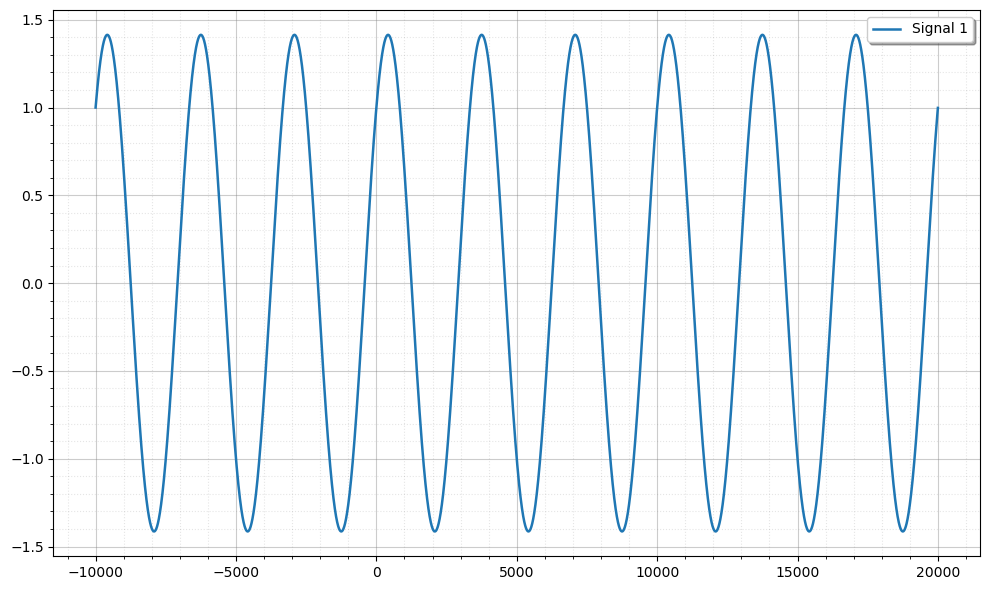

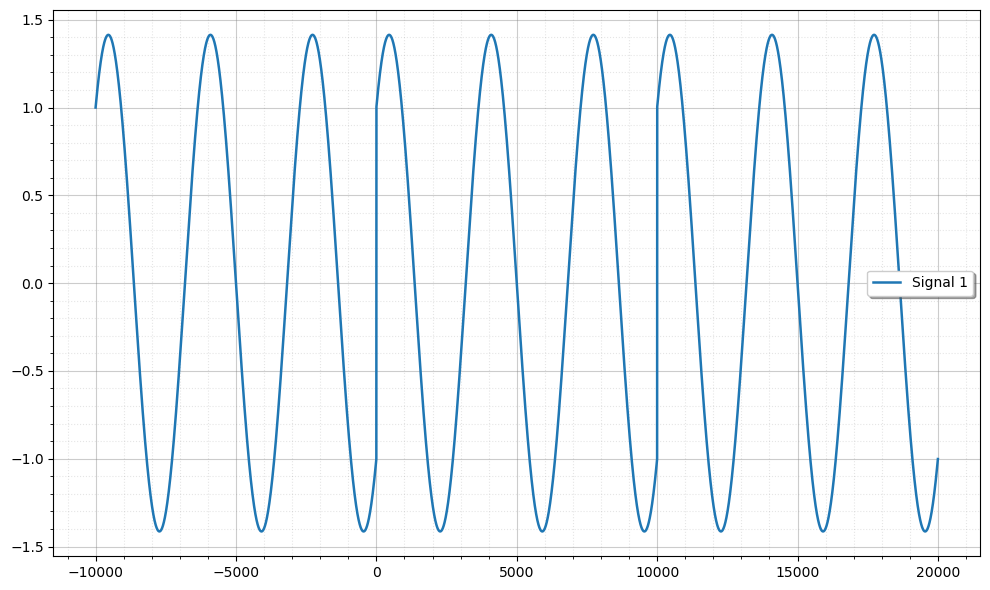

In [150]:
N_size = 10000

k_arr = np.arange(N_size)

k_arr_expanded = np.concatenate((k_arr - N_size, k_arr, k_arr + N_size))

x_k = lambda m: np.cos(2 * np.pi / N_size * m * k_arr) + np.sin(2 * np.pi / N_size * m * k_arr)

x_k_m3 = x_k(3)
x_k_m275 = x_k(2.75)

x_k_repeated_m3 = np.tile(x_k_m3, reps=3)
x_k_repeated_m275 = np.tile(x_k_m275, reps=3)

plot_tools.plot_signals(x_k_repeated_m3, k_arr_expanded)
plot_tools.plot_signals(x_k_repeated_m275, k_arr_expanded)

# К сдаче

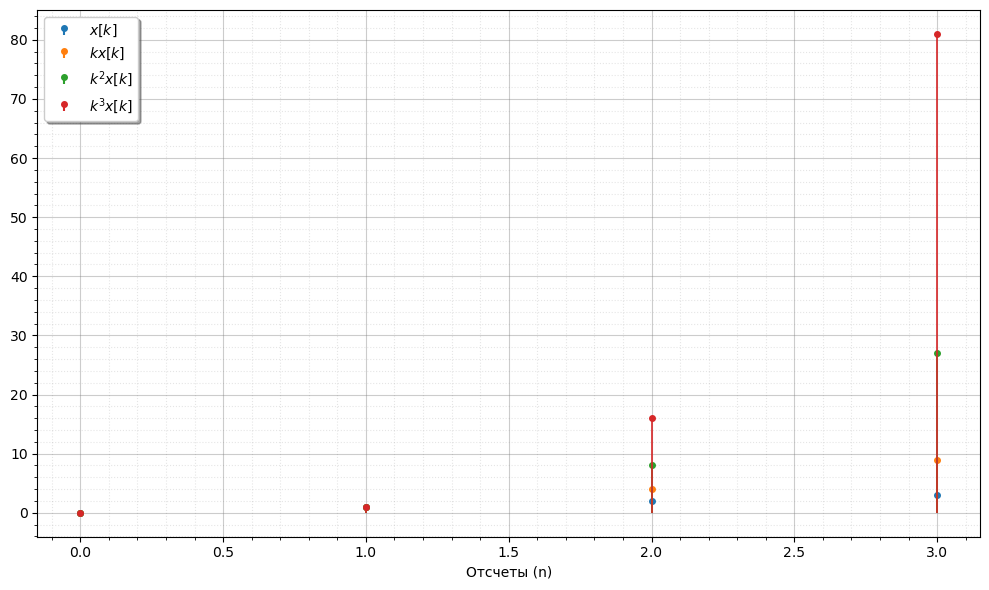

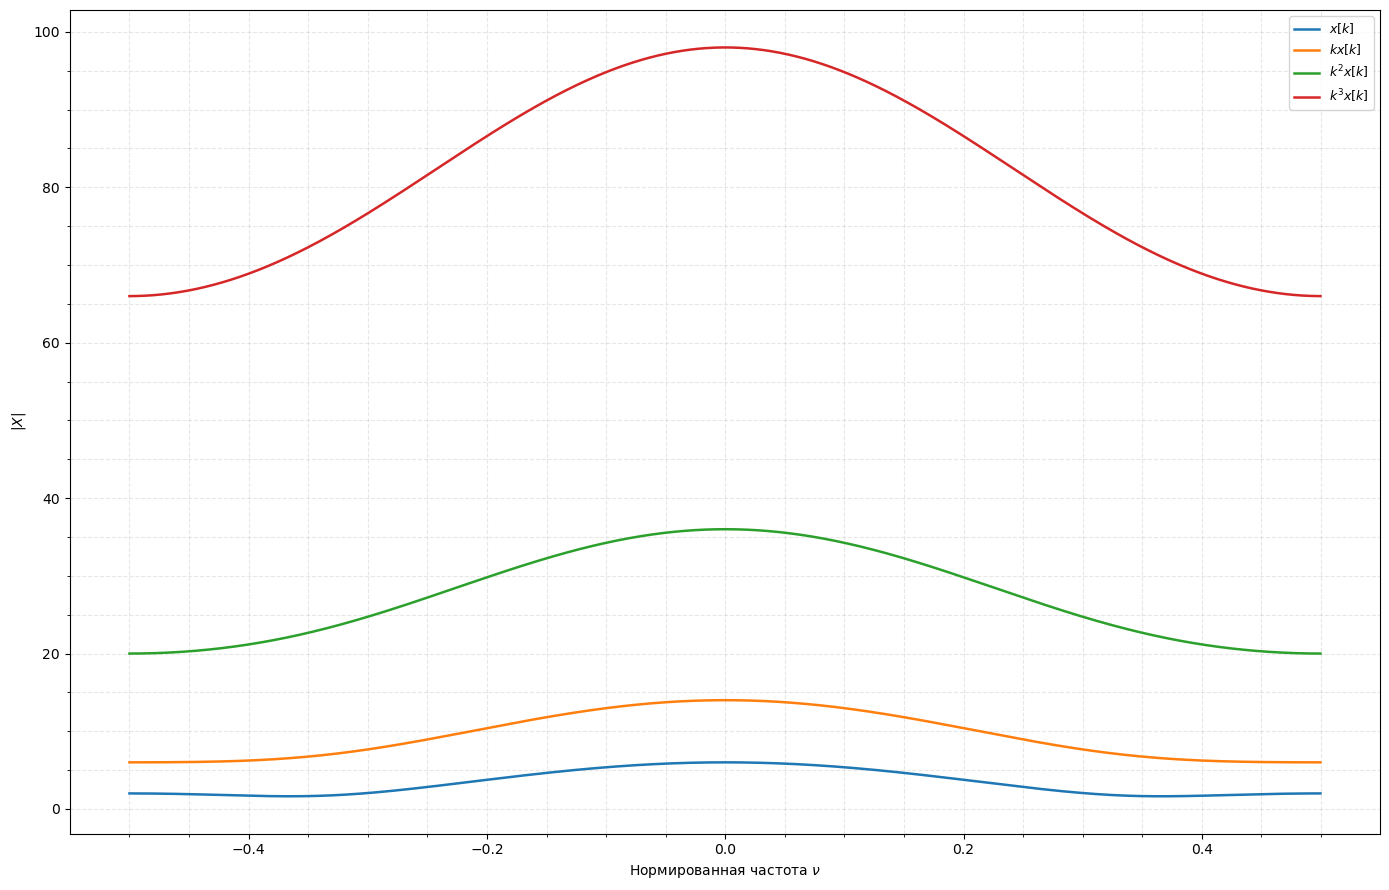

(array([-0.5       , -0.49951172, -0.49902344, ...,  0.49853516,
         0.49902344,  0.49951172], shape=(2048,)),
 [array([-2.        +0.j        , -1.99990588+0.01840745j,
         -1.99962352+0.036813j  , ..., -1.99915295-0.05521473j,
         -1.99962352-0.036813j  , -1.99990588-0.01840745j], shape=(2048,)),
  array([-6.        +0.j        , -5.99968939+0.06135821j,
         -5.9987576 +0.1227103j , ..., -5.99720472-0.18405015j,
         -5.9987576 -0.1227103j , -5.99968939-0.06135821j], shape=(2048,)),
  array([-20.        +0.j        , -19.99900229+0.20248226j,
         -19.99600927+0.40494529j, ..., -19.9910212 -0.60736985j,
         -19.99600927-0.40494529j, -19.99900229-0.20248226j], shape=(2048,)),
  array([-66.        +0.j        , -65.9968657 +0.65039794j,
         -65.98746307+1.30073639j, ..., -65.97179296-1.95095588j,
         -65.98746307-1.30073639j, -65.9968657 -0.65039794j], shape=(2048,))])

In [94]:
# 1.4

N = 4

k_arr = np.arange(N)

x_arr = k_arr

k1_x_arr = k_arr * x_arr

k2_x_arr = k_arr ** 2 * x_arr

k3_x_arr = k_arr ** 3 * x_arr

plot_tools.plot_signals([x_arr, k1_x_arr, k2_x_arr, k3_x_arr], labels=['$x[k]$', '$k x[k]$', '$k^2 x[k]$', '$k^3 x[k]$'], as_stem=True)

plot_tools.compute_dtft_analysis([x_arr, k1_x_arr, k2_x_arr, k3_x_arr], labels=['$x[k]$', '$k x[k]$', '$k^2 x[k]$', '$k^3 x[k]$'], plot_results=True, figsize=(14, 9))